# Motif-count heatmaps
## Imports & global settings

This tutorial builds motif-count heatmaps from motif text files.
We will:

- Parse each file name as `<RBP>_<Cell>.txt`
- Count how many motifs exist per file by counting occurrences of `#<number>`
- Build a **Cell × RBP** matrix (pivot table)
- Optionally filter RBPs based on how many cell lines they appear in
- Plot heatmaps with **stable, reproducible ordering**

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib
import matplotlib as mpl

matplotlib.rcParams["font.family"] = "Calibri"
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"]  = 42

# Input folder containing motif files
folder_path = r"../motif_resources/all_seq_struct_motif"
# Shared colormap
CUSTOM_CMAP = LinearSegmentedColormap.from_list("custom_blue", ["#EBECF3", "#61689e"])


## Count motifs in one file

**Expected file content pattern**

Each motif block starts with a header like:

- `ABCF1_K562#1`
- `ABCF1_K562#2`
- ...

So the number of motifs can be counted by searching for regex `#\d+`.

This function is the **core parser** for motif counts.


In [2]:
def count_motifs_in_file(file_path: str, pattern: str = r"#\d+") -> int:
    """
    Count motifs in a motif text file by regex.

    Parameters
    ----------
    file_path : str
        Path to a motif text file.
    pattern : str
        Regex pattern identifying motif headers (default: '#<digits>').

    Returns
    -------
    int
        Number of motifs found in the file.
    """
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
    return len(re.findall(pattern, content))


## Parse `<RBP>_<Cell>.txt` filenames

We assume each file is named:

- `<RBP>_<Cell>.txt`

Example:

- `ABCF1_K562.txt` → RBP=`ABCF1`, Cell=`K562`

Files that do not match this naming rule will be skipped.


In [3]:
def parse_rbp_cell_from_filename(filename: str) -> tuple[str, str] | None:
    """
    Parse (RBP, Cell) from a filename like '<RBP>_<Cell>.txt'.

    Returns None if the filename does not match the expected pattern.
    """
    if not filename.endswith(".txt"):
        return None
    stem = filename[:-4]  # remove ".txt"
    if "_" not in stem:
        return None
    rbp, cell = stem.split("_", 1)
    return rbp, cell


## Build a Cell × RBP motif count matrix

This function scans the folder, counts motifs per file, and returns a pivot table:

- Rows: Cell lines
- Columns: RBPs
- Values: motif counts

Missing values are filled with 0.

This matrix is the input for **all later filtering and plotting**.


In [4]:
def build_count_matrix(folder: str) -> pd.DataFrame:
    """
    Build a Cell x RBP motif count matrix from motif text files in a folder.

    Parameters
    ----------
    folder : str
        Folder containing motif files.

    Returns
    -------
    pd.DataFrame
        Pivot table with index=Cell, columns=RBP, values=Count (filled with 0).
    """
    rows = []
    for fname in os.listdir(folder):
        parsed = parse_rbp_cell_from_filename(fname)
        if parsed is None:
            continue
        rbp, cell = parsed

        fpath = os.path.join(folder, fname)
        count = count_motifs_in_file(fpath)
        rows.append({"RBP": rbp, "Cell": cell, "Count": count})

    df = pd.DataFrame(rows)
    mat = df.pivot(index="Cell", columns="RBP", values="Count").fillna(0)
    return mat


## Stable column sorting (single-key)

**Goal**: Sort heatmap columns (RBPs) by a specific cell row (descending).

Problem:
- When many values tie (e.g., many zeros), `sort_values()` can produce different tie orders across machines.

Solution:
- Use a deterministic tie-break:
  1) Start from `sorted(RBP names)` (alphabetical)
  2) Apply a *stable* sort by values (`kind="mergesort"`)

This guarantees identical results across machines.


In [5]:
def stable_sort_columns_by_single_cell(log_data: pd.DataFrame, cell: str) -> list[str]:
    """
    Stable sort columns by a single row (cell) in descending order,
    using RBP name (ascending) as the final tie-break.

    Parameters
    ----------
    log_data : pd.DataFrame
        Log-transformed matrix (rows=cells, columns=RBPs).
        We use log-values so that column ordering matches what is shown in the heatmap.
    cell : str
        The row name used as the sorting key (e.g., 'K562').

    Returns
    -------
    list[str]
        Column names ordered deterministically.
    """
    # Deterministic base order for ties
    cols0 = sorted(log_data.columns)

    if cell not in log_data.index:
        return cols0

    s = log_data.loc[cell, cols0]
    return s.sort_values(ascending=False, kind="mergesort").index.tolist()


## Stable column sorting (multi-key)

**Goal**: Sort heatmap columns by multiple cells in priority order:

Example desired:
- HepG2 (desc) → Hela (desc) → HEK293T (desc) → HEK293 (desc)

We achieve a multi-key sort by:
- Starting from alphabetical base order (tie-break),
- Applying stable sorts from the **last key to the first key**.

Because the sort is stable, earlier keys preserve the ordering established by later keys,
equivalent to a multi-key sort.


In [6]:
def stable_sort_columns_by_multiple_cells(log_data: pd.DataFrame, sort_cells: list[str]) -> list[str]:
    """
    Stable multi-key sorting of columns using multiple rows (cells) in descending order.

    Parameters
    ----------
    log_data : pd.DataFrame
        Log-transformed matrix (rows=cells, columns=RBPs).
    sort_cells : list[str]
        Cell names in priority order:
        - First element is the primary key
        - Later elements are lower-priority keys

    Returns
    -------
    list[str]
        Deterministically ordered column names.
    """
    cols = sorted(log_data.columns)  # deterministic tie-break base order
    present_cells = [c for c in sort_cells if c in log_data.index]

    # Apply stable sorts from last -> first key
    for cell in reversed(present_cells):
        s = log_data.loc[cell, cols]
        cols = s.sort_values(ascending=False, kind="mergesort").index.tolist()

    return cols


## Apply a fixed display order

Sometimes we want the heatmap to follow a *manually chosen order*:

- A fixed cell order (rows)
- A fixed RBP order (columns)

This function:
- Keeps only items that exist in the data
- Reindexes rows and columns to the fixed order


In [7]:
def apply_fixed_order(
    data: pd.DataFrame,
    *,
    cell_order: list[str],
    rbp_order: list[str],
) -> pd.DataFrame:
    """
    Reindex a (Cell x RBP) matrix using fixed row/column order.

    Parameters
    ----------
    data : pd.DataFrame
        Matrix with rows=cells and columns=RBPs.
    cell_order : list[str]
        Desired cell order (top-to-bottom).
    rbp_order : list[str]
        Desired RBP order (left-to-right).

    Returns
    -------
    pd.DataFrame
        Reindexed matrix (missing rows/cols dropped).
    """
    cells = [c for c in cell_order if c in data.index]
    rbps = [r for r in rbp_order if r in data.columns]
    return data.reindex(index=cells, columns=rbps)


## Plot a heatmap

We plot `ln(count + 1)` so that large counts are compressed but zeros remain 0.

Formatting choices:
- Calibri font
- Grey grid lines
- Bigger tick/font sizes
- PDF output (vector-friendly)


In [8]:
def plot_heatmap(
    data: pd.DataFrame,
    out_pdf: str,
    *,
    cell_row_order: list[str],
    column_order: list[str] | None = None,
    cmap=CUSTOM_CMAP,
    cbar_label: str = "ln(Motif Counts)",
    fig_scale: float = 0.38,
    fig_height: float = 4.6,
    show: bool = True,
) -> None:
    """
    Plot and save a heatmap of motif counts (log-transformed).

    Parameters
    ----------
    data : pd.DataFrame
        Raw motif count matrix (rows=cells, columns=RBPs).
    out_pdf : str
        Output PDF filename.
    cell_row_order : list[str]
        Desired order of cell rows on y-axis.
    column_order : list[str] | None
        Desired order of RBP columns on x-axis.
        If None, uses current column order.
    cmap : matplotlib colormap
        Heatmap colormap.
    cbar_label : str
        Colorbar label.
    fig_scale : float
        Width scaling factor per column.
    fig_height : float
        Figure height (inches).
    show : bool
        If True, display figure in notebook output; always saved to PDF.

    Returns
    -------
    None
    """
    # Log transform to match your label "ln(...)"
    log_data = np.log(data + 1)

    # Reindex rows (cells) to fixed display order
    rows = [c for c in cell_row_order if c in log_data.index]
    log_data = log_data.reindex(index=rows)

    # Reindex columns (RBPs) if provided
    if column_order is not None:
        cols = [c for c in column_order if c in log_data.columns]
        log_data = log_data.loc[:, cols]

    # Plot
    plt.figure(figsize=(max(10, log_data.shape[1] * fig_scale), fig_height), constrained_layout=True)
    ax = sns.heatmap(
        log_data,
        cmap=cmap,
        linewidths=1.5,
        linecolor="grey",
        cbar_kws={"label": cbar_label},
        xticklabels=True,
        yticklabels=True,
    )

    # Colorbar style
    colorbar = ax.collections[0].colorbar
    colorbar.ax.yaxis.label.set_size(20)
    colorbar.ax.tick_params(labelsize=20)

    # Axis style
    ax.set_xlabel("")
    ax.set_ylabel("")
    # calibri_prop = fm.FontProperties(fname=CALIBRI_TTF)
    # ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=20, fontproperties=calibri_prop)
    # ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=20, fontproperties=calibri_prop)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=20, fontname="Calibri")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=20, fontname="Calibri")

    # Save
    plt.savefig(out_pdf, format="pdf", dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    plt.close()



## Run: fixed-order heatmap

This is the minimal pipeline:

1. Build the motif count matrix (Cell × RBP)
2. Optionally filter RBPs (e.g., appearing in >=2 cell lines)
3. Apply fixed row/column order
4. Plot and save PDF


findfont: Font family ['Calibri'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Calibri'] not found. Falling back to DejaVu Sans.


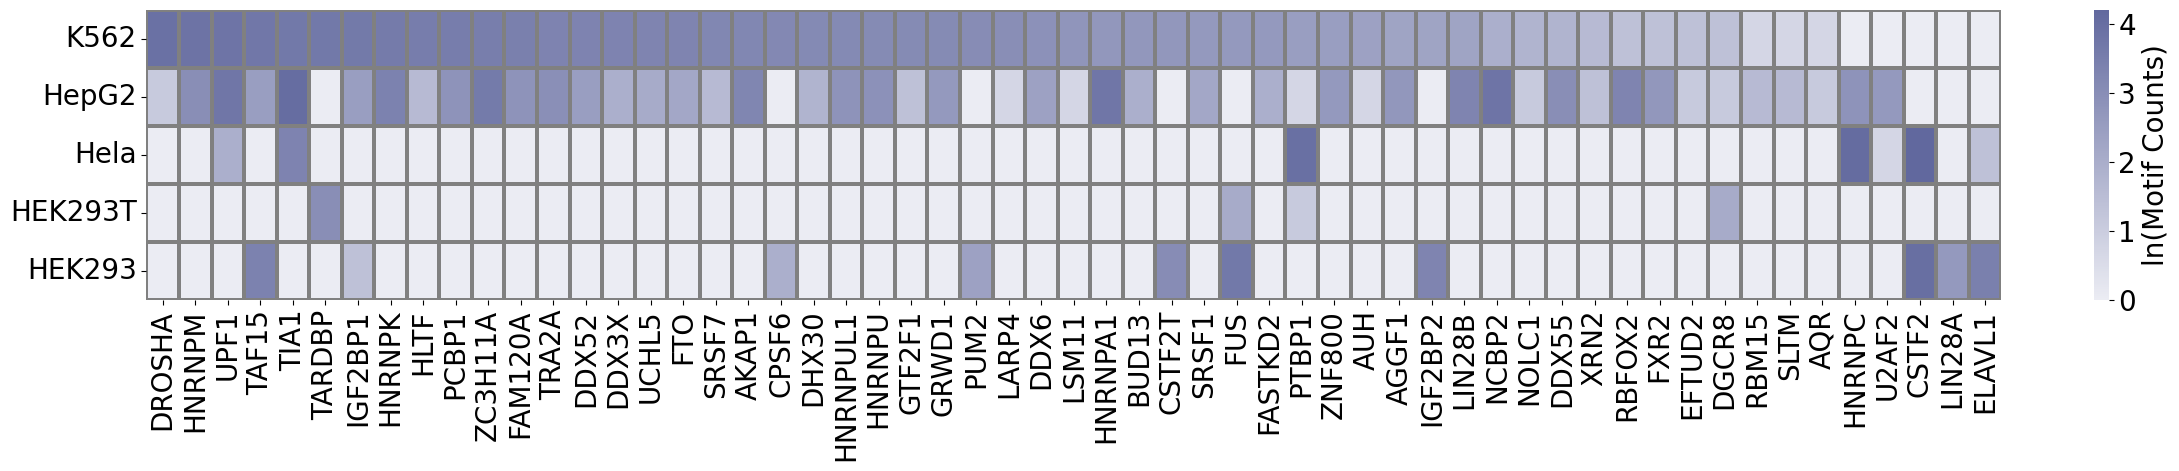

In [9]:
# -----------------------------
# Fixed display order
# -----------------------------
fixed_cell_order = ["K562", "HepG2", "Hela", "HEK293T", "HEK293"]
fixed_rbp_order = [
    "DROSHA","HNRNPM","UPF1","TAF15","TIA1","TARDBP","IGF2BP1","HNRNPK","HLTF","PCBP1",
    "ZC3H11A","FAM120A","TRA2A","DDX52","DDX3X","UCHL5","FTO","SRSF7","AKAP1","CPSF6",
    "DHX30","HNRNPUL1","HNRNPU","GTF2F1","GRWD1","PUM2","LARP4","DDX6","LSM11","HNRNPA1",
    "BUD13","CSTF2T","SRSF1","FUS","FASTKD2","PTBP1","ZNF800","AUH","AGGF1","IGF2BP2",
    "LIN28B","NCBP2","NOLC1","DDX55","XRN2","RBFOX2","FXR2","EFTUD2","DGCR8","RBM15",
    "SLTM","AQR","HNRNPC","U2AF2","CSTF2","LIN28A","ELAVL1"
]

# 1) Build matrix
heatmap_data = build_count_matrix(folder_path)

# 2) (Optional) filter RBPs present in >=2 cell lines
valid_rbps = (heatmap_data > 0).sum(axis=0)
filtered_data = heatmap_data.loc[:, valid_rbps[valid_rbps >= 2].index]

# 3) Apply fixed order
fixed_data = apply_fixed_order(filtered_data, cell_order=fixed_cell_order, rbp_order=fixed_rbp_order)

# 4) Plot
plot_heatmap(fixed_data, "motif_counts.pdf", cell_row_order=fixed_cell_order, show=True)
